In [1]:
import numpy as np
import sys, os, time
import torch
import torch.nn as nn
import data, architecture
import optuna
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'serif'

/home/vk9342/.conda/envs/usrp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# optuna dashboard
# dotted line on how does the 1st network perform mse 
# try 79 and 40 as final hidden layer 
# maybe confusing neutrinos and sigma 8
# All mses summed togetehr 

### Get top 10 nwLH model out puts

In [5]:
################################### INPUT ############################################
# data parameters
f_Pk_norm = None #file with Pk to normalize Pk
seed      = 1         #seed to split data in train/valid/test
mode      = 'test'   #'train','valid','test' or 'all'

cosm_type = 'fR'
Pk_type = 'Pk'
log = True
model_type = 'dynamic' #or 'dynamic' 'dynamic_fixed_final'
output_size = 7
input_size  = 79  #dimensions of input data
final_hidden_layer_size = 10

n_sims_nwLH = [25, 75, 125, 175]
n_sims_BSQ = [0]

additional_extension = '_lcdm'

In [6]:
for n_BSQ in n_sims_BSQ: 
    for n_nwLH in n_sims_nwLH:
        n = []
        mse = []
    
        if n_BSQ == 0:
            name = 'transfer10_network2_'+str(n_nwLH)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ' #transfer40 for nwLH - BSQ
            # additional_extension = ''   #used in fout
            f_Pk      = 'Pk_files/'+str(n_nwLH)+'_'+str(Pk_type)+'_'+str(cosm_type)+additional_extension+'.npy'
            input_size  = 79
        else:
            name = 'transfer10_network2_'+str(n_nwLH)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ' 
            extension = 'fhl10'
            f_Pk      = 'Pk_files/'+str(n_nwLH)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ_'+Pk_type + additional_extension+'_'+str(extension)+'_fortransfer.npy'
            input_size  = 10
            
        # f_Pk      = 'Pk_files/'+str(n_BSQ)+'_'+str(Pk_type)+'_'+str(cosm_type)+'.npy'
        # param_ext = ''
        f_params  = '../real_params/'+str(n_nwLH)+'_'+str(cosm_type)+'_'+Pk_type+'_params'+additional_extension+'.txt'  #filtered for BSQ

        study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
        mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'

        print(name)
        print(f_params)
        print(f_Pk)
        
    
        # architecture parameters
        # training parameters
        batch_size = 32
        # optuna parameters
        storage    = 'sqlite:///nwLH.db'
        
        
        
        ######################################################################################
        ######################################################################################
        # use GPUs if available
        if torch.cuda.is_available():
            print("CUDA Available")
            device = torch.device('cuda')
        else:
            print('CUDA Not Available')
            device = torch.device('cpu')
        
        # load the optuna study
        study = optuna.load_study(study_name=study_name, storage=storage)
        
        # get the scores of the study trials
        values = np.zeros(len(study.trials))
        completed = 0
        
        for i,t in enumerate(study.trials):
            values[i] = t.value
            if t.value is not None:  completed += 1
        
        # get the info of the best trial
        indexes = np.argsort(values)
        for indx in range(10):
            trial = study.trials[indexes[indx]]
            # name = 'transfer10_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ' 
            fout = 'results/Results_'+mode+'_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(indx)+additional_extension+'.txt'
            # fout = 'results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+'transfer10_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ'+'model'+str(indx)+'.txt'
            
            # print("\nTrial number {}".format(trial.number))
            # print("Value: %.5e"%trial.value)
            for key, value in trial.params.items():
                lr       = trial.params['lr']
                wd       = trial.params['wd']
                n_layers       = trial.params['n_layers']
                p       = trial.params['dropout_l']
                
            fmodel = mother +'model_%d.pt'%trial.number

            
        
            # # generate the architecture
            if model_type == 'dynamic_fixed_final':
                out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
                model = architecture.dynamic_model_fixed_final(trial, input_size, output_size, 
                                                               final_hidden_layer_size, 
                                                               n_layers, p, out_fs,
                                                               max_neurons_layers=500)
                
            elif model_type == 'dynamic':
                out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers)]
                model = architecture.dynamic_model(trial, input_size, output_size,
                                                   n_layers, p, out_fs,
                                                   max_neurons_layers=500)   

            else:
                print('not a valid model')

            # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'layer sizes: ', out_fs)
            # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'n layers: ', n_layers)
    
            
            model.to(device)  
            
            # load best-model, if it exists
            if os.path.exists(fmodel):  
                print('Loading model...')
                model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
            else:
                raise Exception('model doesnt exists!!!')
            
            
            # define loss function
            criterion = nn.MSELoss() 
            
            # get the data
            test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
                                              batch_size, shuffle=False, workers=1, 
                                              cosm_type =cosm_type, log=log, 
                                              shuffle_all = True)
            test_points = 0
            for x,y in test_loader:  test_points += x.shape[0]
            
            # define the arrays containing the true and predicted value of the parameters
            params  = output_size
            results = np.zeros((test_points, 2*params), dtype=np.float32)
            
            # test the model
            test_loss, points = 0.0, 0
            model.eval()
            with torch.no_grad():
                for x, y in test_loader:
                    bs   = x.shape[0]  #batch size
                    x, y = x.to(device), y.to(device)
                    y_NN = model(x)
                    test_loss += (criterion(y_NN, y).item())*bs
                    results[points:points+bs,0*params:1*params] = y.cpu().numpy()
                    results[points:points+bs,1*params:2*params] = y_NN.cpu().numpy()
                    points    += bs
            test_loss /= points
            print('Test loss:', test_loss)
    
            np.savetxt(fout, results)


transfer10_network2_25_fR_0_BSQ
../real_params/25_fR_Pk_params_lcdm.txt
Pk_files/25_Pk_fR_lcdm.npy
CUDA Available
Loading model...
Test loss: 0.22357459366321564
Loading model...
Test loss: 0.07652463018894196
Loading model...
Test loss: 0.1708676666021347
Loading model...
Test loss: 0.0962640792131424
Loading model...
Test loss: 0.07433737814426422
Loading model...
Test loss: 0.07191794365644455
Loading model...
Test loss: 0.0808710977435112
Loading model...
Test loss: 0.07947935163974762
Loading model...
Test loss: 0.085841104388237
Loading model...
Test loss: 0.07682698965072632
transfer10_network2_75_fR_0_BSQ
../real_params/75_fR_Pk_params_lcdm.txt
Pk_files/75_Pk_fR_lcdm.npy
CUDA Available
Loading model...
Test loss: 0.0372893288731575
Loading model...
Test loss: 0.038340043276548386
Loading model...
Test loss: 0.0400003083050251
Loading model...
Test loss: 0.04132584109902382
Loading model...
Test loss: 0.04011484608054161
Loading model...
Test loss: 0.042385831475257874
Loading m

### Plot MSEs for transfer learning MPk

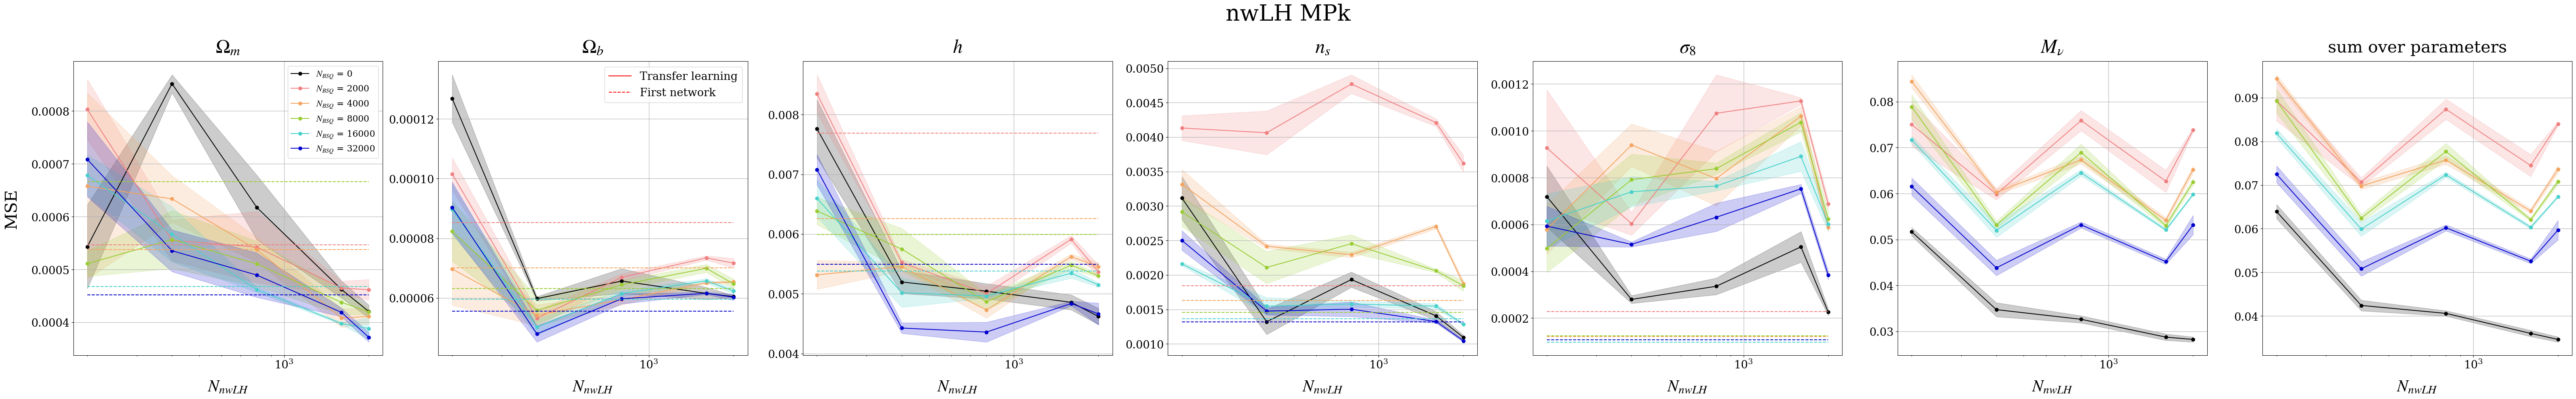

In [69]:
Pk_type = 'MPk'
cosm_type = 'nwLH'
n_sims_nwLH = [200 , 400, 800, 1600, 2000]
n_sims_BSQ = [0 , 2000, 4000, 8000, 16000, 32000]

minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
colors = ['black', 'lightcoral', 'sandybrown', 'yellowgreen', 'mediumturquoise', 'mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']
num_params = 6

fig, axes = plt.subplots(1, 7, figsize=(65, 10), sharey=False)

for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_avg_param_sum = []
    all_mse_std = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_std_param_sum = []


    for n_nwLH in n_sims_nwLH:
        mse_all_models = []

        for n_model in range(3):
            if n_BSQ == 0:
                additional_extension = 'v2'
            else:
                additional_extension = ''
            name = 'transfer10_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
        mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
        
        all_mse_avg.append(np.mean(mse_all_models, axis=0))  # (6,)
        all_mse_std.append(np.std(mse_all_models, axis=0))  # (6,)
        
        all_mse_avg_param_sum.append(np.mean(mse_param_sum))
        all_mse_std_param_sum.append(np.std(mse_param_sum))

        # for param_idx in range(num_params):
        #     ax = axes[param_idx]
        #     ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
        #     # ax.set_xscale('log')
        # axes[6].scatter([n_nwLH]*10, mse_param_sum, color=colors[color_idx], s=5)

    
    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
    all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
    all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
    all_mse_std_param_sum = np.array(all_mse_std_param_sum)

    for param_idx in range(num_params):
        ax = axes[param_idx]
        if param_idx == 0:
            ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], 
                    color=colors[color_idx], marker='o', label=r'$N_{BSQ}$ = '+str(n_BSQ))
        else: 
            ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], 
                    color=colors[color_idx], marker='o')
        
        ax.fill_between(n_sims_nwLH,
                all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
                all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
                color=colors[color_idx],
                alpha=0.2)
        
        ax.set_title(param_labels[param_idx], fontsize = 35, y=1.02)
        ax.set_xlabel(r'$N_{nwLH}$', fontsize = 30, labelpad=15)
        ax.tick_params(axis='both', labelsize=20)
        
        if param_idx == 0:
            ax.set_ylabel('MSE', fontsize = 30, labelpad=20)
        ax.grid(True)
        ax.set_xscale('log')
    
    axes[6].plot(n_sims_nwLH, all_mse_avg_param_sum, color = colors[color_idx],  
                 marker='o', label=r'$N_{BSQ}$ = '+str(n_BSQ))
    axes[6].fill_between(n_sims_nwLH,
                all_mse_avg_param_sum - all_mse_std_param_sum,
                all_mse_avg_param_sum + all_mse_std_param_sum,
                color=colors[color_idx],
                alpha=0.2)
    axes[6].grid(True)
    axes[6].set_title('sum over parameters',  fontsize = 30, y=1.02)
    axes[6].set_xlabel(r'$N_{{nwLH}}$', fontsize = 30, labelpad=15)
    axes[6].tick_params(axis='both', labelsize=20)
    axes[6].set_xscale('log')



## First network
all_mse = []
for n_BSQ in [2000, 4000, 8000, 16000, 32000]: 
    name = 'transfer10_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
    num_params = 5
    additional_extension = ''
    test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+str(additional_extension)+'.txt')
    test_true = test[:, :num_params]
    test_pred = test[:, num_params:]
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    test_true = test_true * (maximum - minimum) + minimum
    test_pred = test_pred * (maximum - minimum) + minimum
    mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
    all_mse.append(mse)  # 5 n sims x 5 cosmo params

all_mse = np.array(all_mse)
for param_indx in range (5):
    ax = axes[param_indx]
    for BSQ_indx in range (5):
        ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=2000, linestyle = '--', color = colors[BSQ_indx+1])



from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='red', linestyle='-', label='Transfer learning'),
    Line2D([0], [0], color='red', linestyle='--', label='First network'),
]
axes[1].legend(handles=legend_elements, fontsize=20)

# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for ax in axes:
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0].legend(loc='upper right', fontsize=16)
    plt.suptitle('nwLH MPk', fontsize = 40, y=1.0)
plt.tight_layout()
plt.show()




## Plot MSE Pk

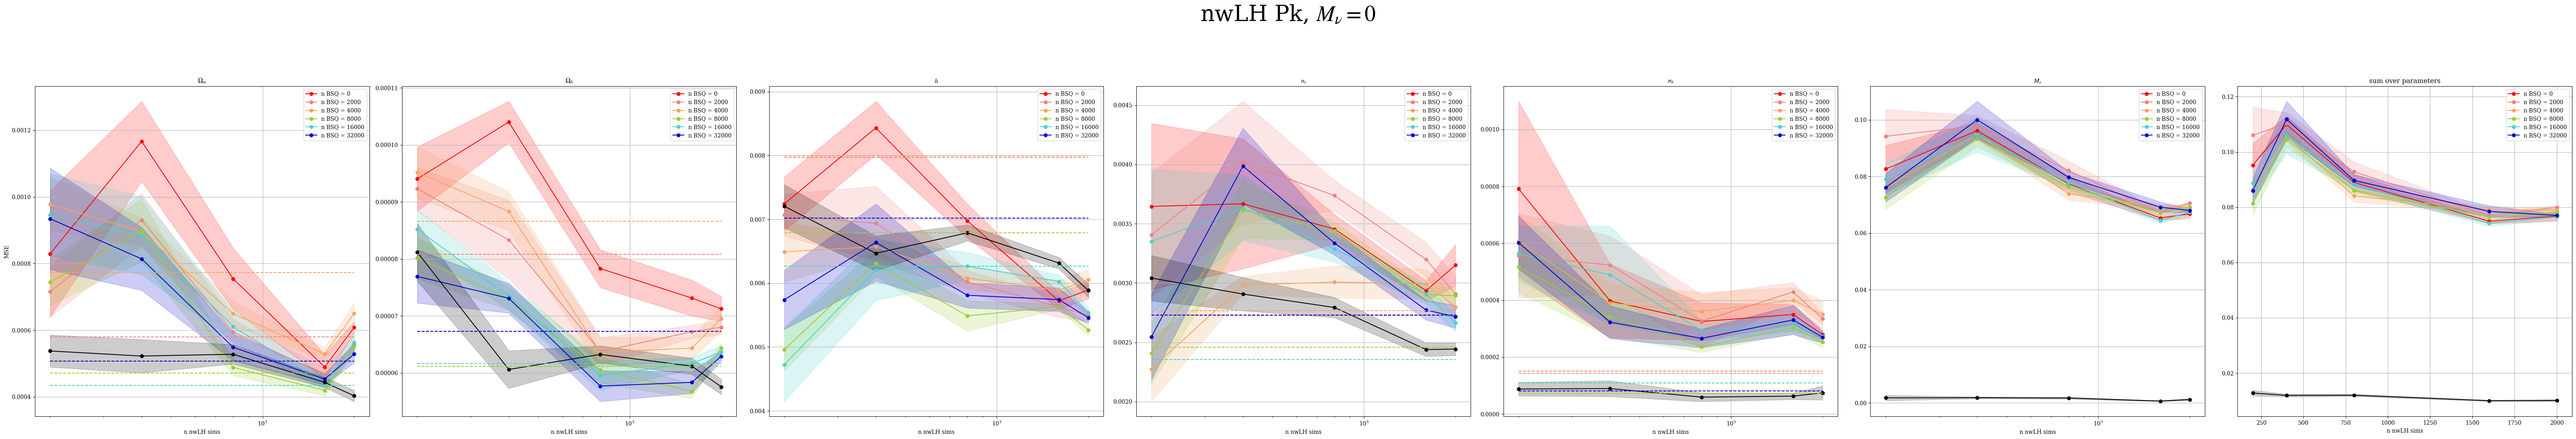

In [16]:
Pk_type = 'Pk'
cosm_type = 'nwLH'
n_sims_nwLH = [200 , 400, 800, 1600, 2000]
n_sims_BSQ = [0, 2000, 4000, 8000, 16000, 32000]

minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
colors = ['red', 'lightcoral', 'sandybrown', 'yellowgreen', 'mediumturquoise', 'mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']
num_params = 6

fig, axes = plt.subplots(1, 7, figsize=(65, 10), sharey=False)


for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_avg_param_sum = []
    all_mse_std = []
    all_mse_std_param_sum = []

    for n_nwLH in n_sims_nwLH:
        mse_all_models = []

        for n_model in range(10):
            additional_extension = ''
            name = 'transfer10_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
        mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
         
        all_mse_avg.append(np.mean(mse_all_models, axis=0))# (6,)
        all_mse_std.append(np.std(mse_all_models, axis=0))# (6,)
        
        all_mse_avg_param_sum.append(np.mean(mse_param_sum))
        all_mse_std_param_sum.append(np.std(mse_param_sum))

        # for param_idx in range(num_params):
        #     ax = axes[param_idx]
        #     ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
        #     # ax.set_xscale('log')
        # axes[6].scatter([n_nwLH]*10, mse_param_sum, color=colors[color_idx], s=5)

    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
    all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
    all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
    all_mse_std_param_sum = np.array(all_mse_std_param_sum)

    for param_idx in range(num_params):
        ax = axes[param_idx]
        ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color=colors[color_idx], marker='o', label='n BSQ = '+str(n_BSQ))
        ax.fill_between(n_sims_nwLH,
                all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
                all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
                color=colors[color_idx],
                alpha=0.2)
        ax.set_title(param_labels[param_idx])
        ax.set_xlabel('n nwLH sims')
        if param_idx == 0:
            ax.set_ylabel('MSE')
        ax.grid(True)
        ax.set_xscale('log')

    axes[6].plot(n_sims_nwLH, all_mse_avg_param_sum, color = colors[color_idx],  marker='o', label='n BSQ = '+str(n_BSQ))
    axes[6].fill_between(n_sims_nwLH,
                all_mse_avg_param_sum - all_mse_std_param_sum,
                all_mse_avg_param_sum + all_mse_std_param_sum,
                color=colors[color_idx],
                alpha=0.2)
    axes[6].grid(True)
    axes[6].set_title('sum over parameters')
    axes[6].set_xlabel('n nwLH sims')



all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
all_mse_avg_param_sum = []
all_mse_std = []
all_mse_std_param_sum = []

n_sims_nwLH_BSQ = [2000, 4000, 8000, 16000, 32000]
for n_nwLH in n_sims_nwLH_BSQ:
    mse_all_models = []

    for n_model in range(10):
        additional_extension = ''
        name = 'transfer10_network2_'+str(n_nwLH)+'_nwLH_BSQ_'+ '0_BSQ'
        test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_nwLH_BSQ_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

        test_true = test[:, :num_params]
        test_pred = test[:, num_params:]
        test_true = test_true * (maximum - minimum) + minimum
        test_pred = test_pred * (maximum - minimum) + minimum

        mask = np.isclose(test_true[:, 5], 0, atol=1e-10)
        test_pred = test_pred[mask]
        test_true = test_true[mask]
        

        mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
        mse_all_models.append(mse)  #size 10 x 6

    mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
    mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
     
    all_mse_avg.append(np.mean(mse_all_models, axis=0))# (6,)
    all_mse_std.append(np.std(mse_all_models, axis=0))# (6,)
    
    all_mse_avg_param_sum.append(np.mean(mse_param_sum))
    all_mse_std_param_sum.append(np.std(mse_param_sum))

    # for param_idx in range(num_params):
    #     ax = axes[param_idx]
    #     ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
    #     # ax.set_xscale('log')
    # axes[6].scatter([n_nwLH]*10, mse_param_sum, color=colors[color_idx], s=5)

all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
all_mse_std_param_sum = np.array(all_mse_std_param_sum)

for param_idx in range(num_params):
    ax = axes[param_idx]
    ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color='black', marker='o',)
    ax.fill_between(n_sims_nwLH,
            all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
            all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
            color='black',
            alpha=0.2)

axes[6].plot(n_sims_nwLH, all_mse_avg_param_sum, color = 'black',  marker='o')
axes[6].fill_between(n_sims_nwLH,
            all_mse_avg_param_sum - all_mse_std_param_sum,
            all_mse_avg_param_sum + all_mse_std_param_sum,
            color='black',
            alpha=0.2)



## First network
all_mse = []
for n_BSQ in [2000, 4000, 8000, 16000, 32000]: 
    name = 'transfer10_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
    num_params = 5
    additional_extension = ''
    test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+str(additional_extension)+'.txt')
    test_true = test[:, :num_params]
    test_pred = test[:, num_params:]
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    test_true = test_true * (maximum - minimum) + minimum
    test_pred = test_pred * (maximum - minimum) + minimum
    mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
    all_mse.append(mse)  # 5 n sims x 5 cosmo params

all_mse = np.array(all_mse)
for param_indx in range (5):
    ax = axes[param_indx]
    for BSQ_indx in range (5):
        ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=2000, linestyle = '--', color = colors[BSQ_indx+1])



for ax in axes:
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.legend(loc='upper right')
plt.suptitle(r'nwLH Pk, $M_{\nu} = 0$', fontsize = 40, y=1.1)
plt.tight_layout()
plt.show()




## LC LH Plot

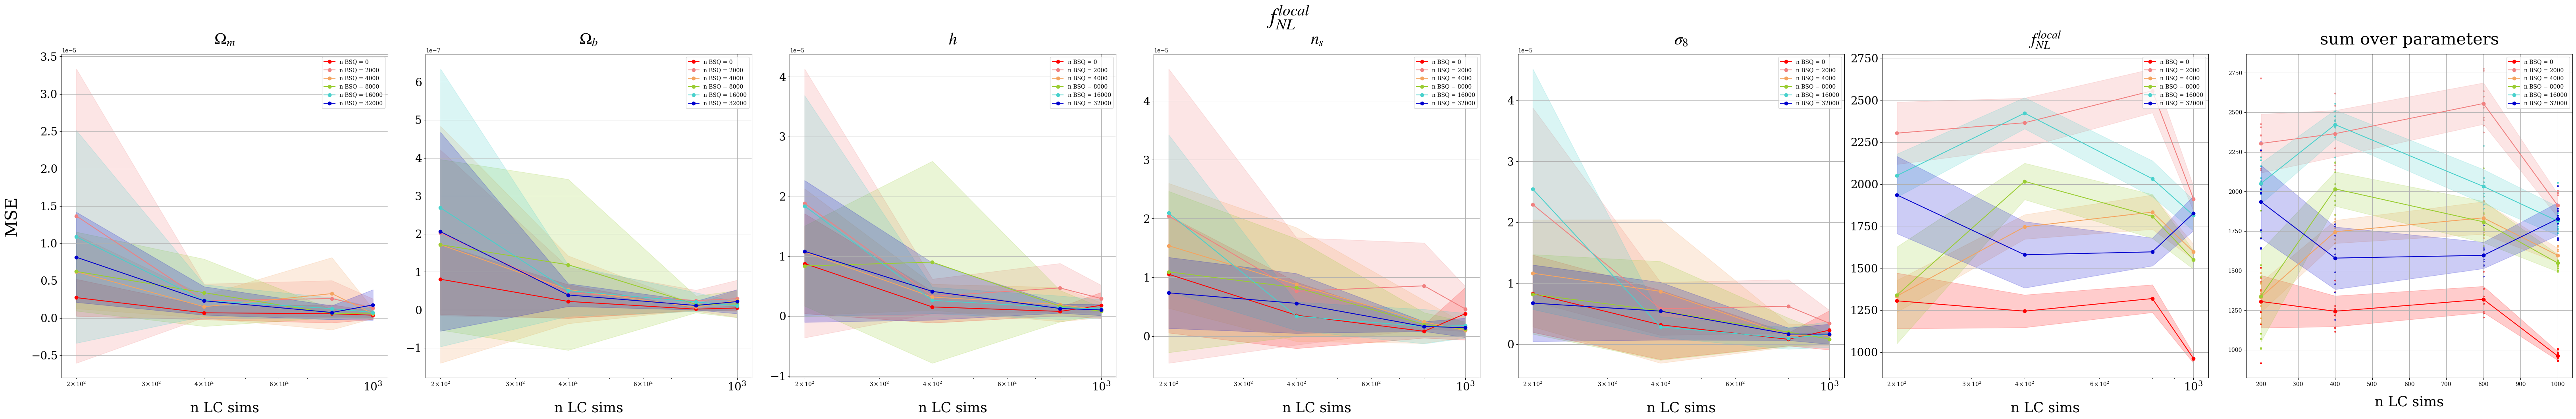

In [28]:
Pk_type = 'Pk'
cosm_type = 'LC'
n_sims_LC = [200 , 400, 800, 1000]
n_sims_BSQ = [0, 2000, 4000, 8000, 16000, 32000]

minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, -300])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 300])
colors = ['red', 'lightcoral', 'sandybrown', 'yellowgreen', 'mediumturquoise', 'mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$f_{NL}^{local}$']
num_params = 6

fig, axes = plt.subplots(1, 7, figsize=(65, 10), sharey=False)

for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_std = []
    all_mse_avg_param_sum = []
    all_mse_std_param_sum = []

    for n_LC in n_sims_LC:
        mse_all_models = []

        for n_model in range(10):
            additional_extension = ''
            name = 'transfer10_network2_'+str(n_LC)+'_LC_'+str(n_BSQ)+'_BSQ'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
        mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
        
        all_mse_avg.append(np.mean(mse_all_models, axis=0))  # (6,)
        all_mse_std.append(np.std(mse_all_models, axis = 0))
                
        all_mse_avg_param_sum.append (np.mean(mse_param_sum))
        all_mse_std_param_sum.append (np.std(mse_param_sum))

        # for param_idx in range(num_params):
        #     ax = axes[param_idx]
        #     ax.scatter([n_LC]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
        #     # ax.set_xscale('log')
        
        axes[6].scatter([n_LC]*10, mse_param_sum, color=colors[color_idx], s=5)

    
    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
    all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
    all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
    all_mse_std_param_sum = np.array(all_mse_std_param_sum)

    for param_idx in range(num_params):
        ax = axes[param_idx]
        ax.plot(n_sims_LC, all_mse_avg[:, param_idx], color=colors[color_idx], marker='o', label='n BSQ = '+str(n_BSQ))
        ax.fill_between(n_sims_LC,
                all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
                all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
                color=colors[color_idx],
                alpha=0.2)
        
        ax.set_title(param_labels[param_idx], fontsize = 30, y=1.02)
        ax.set_xlabel('n LC sims', fontsize = 25, labelpad=15)
        ax.tick_params(axis='both', labelsize=20)
        if param_idx == 0:
            ax.set_ylabel('MSE', fontsize = 30, labelpad=20)
        ax.grid(True)
        ax.set_xscale('log')
    
    axes[6].plot(n_sims_LC, all_mse_avg_param_sum, color = colors[color_idx],  marker='o', label='n BSQ = '+str(n_BSQ))
    axes[6].fill_between(n_sims_LC,
                all_mse_avg_param_sum - all_mse_std_param_sum,
                all_mse_avg_param_sum + all_mse_std_param_sum,
                color=colors[color_idx],
                alpha=0.2)
    axes[6].grid(True)
    axes[6].set_title('sum over parameters', fontsize = 30, y=1.02)
    axes[6].set_xlabel('n LC sims',  fontsize = 25, labelpad=15)



# ## First network
# all_mse = []
# for n_BSQ in [2000, 4000, 8000, 16000, 32000]: 
#     name = 'transfer10_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
#     num_params = 5
#     additional_extension = ''
#     test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+str(additional_extension)+'.txt')
#     test_true = test[:, :num_params]
#     test_pred = test[:, num_params:]
#     minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
#     maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
#     test_true = test_true * (maximum - minimum) + minimum
#     test_pred = test_pred * (maximum - minimum) + minimum
#     mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
#     all_mse.append(mse)  # 5 n sims x 5 cosmo params

# all_mse = np.array(all_mse)
# for param_indx in range (5):
#     ax = axes[param_indx]
#     for BSQ_indx in range (5):
#         ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=2000, linestyle = '--', color = colors[BSQ_indx+1])




# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for ax in axes:
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.suptitle(r'$f_{NL}^{local}$', fontsize = 40, y=1.05)
plt.show()




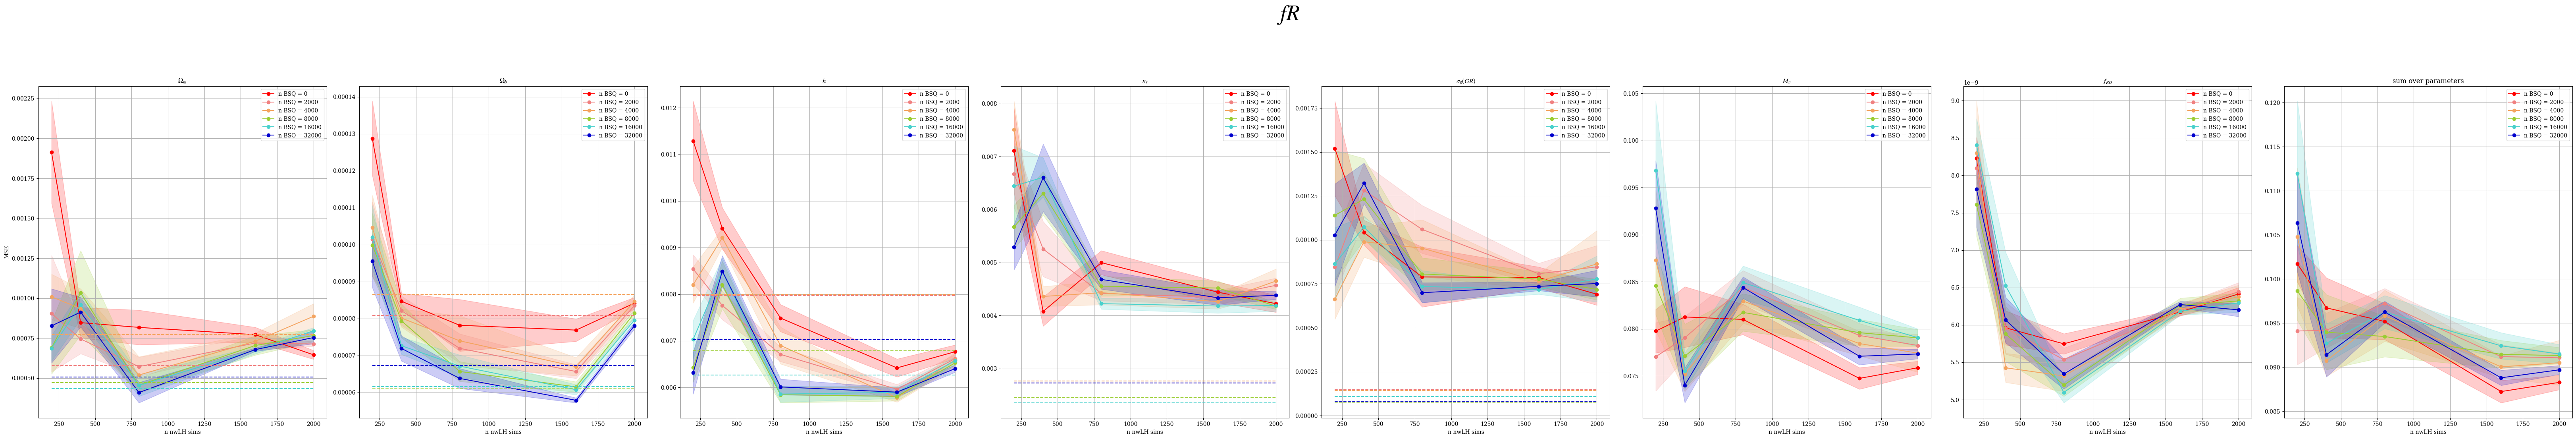

In [31]:
Pk_type = 'Pk'
cosm_type = 'fR'
n_sims_nwLH = [200 , 400, 800, 1600, 2000]
n_sims_BSQ = [0, 2000, 4000, 8000, 16000, 32000]

minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
colors = ['red', 'lightcoral', 'sandybrown', 'yellowgreen', 'mediumturquoise', 'mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8(GR)$', r'$M_{\nu}$', r'$f_{RO}$']
num_params = 7

fig, axes = plt.subplots(1, 8, figsize=(65, 10), sharey=False)

for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_avg_param_sum = []
    all_mse_std = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_std_param_sum = []


    for n_nwLH in n_sims_nwLH:
        mse_all_models = []

        for n_model in range(10):
            additional_extension = '_lcdm'
            name = 'transfer10_network2_'+str(n_nwLH)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
        mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
        
        all_mse_avg.append(np.mean(mse_all_models, axis=0))  # (6,)
        all_mse_std.append(np.std(mse_all_models, axis=0))  # (6,)
        
        all_mse_avg_param_sum.append(np.mean(mse_param_sum))
        all_mse_std_param_sum.append(np.std(mse_param_sum))

        # for param_idx in range(num_params):
        #     ax = axes[param_idx]
        #     ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
        #     # ax.set_xscale('log')
        # axes[6].scatter([n_nwLH]*10, mse_param_sum, color=colors[color_idx], s=5)

    
    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
    all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
    all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
    all_mse_std_param_sum = np.array(all_mse_std_param_sum)

    for param_idx in range(num_params):
        ax = axes[param_idx]
        ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color=colors[color_idx], marker='o', label='n BSQ = '+str(n_BSQ))
        ax.fill_between(n_sims_nwLH,
                all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
                all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
                color=colors[color_idx],
                alpha=0.2)
        ax.set_title(param_labels[param_idx])
        ax.set_xlabel('n nwLH sims')
        if param_idx == 0:
            ax.set_ylabel('MSE')
        ax.grid(True)
        # ax.set_xscale('log')
    axes[num_params].plot(n_sims_nwLH, all_mse_avg_param_sum, color = colors[color_idx],  marker='o', label='n BSQ = '+str(n_BSQ))
    axes[num_params].fill_between(n_sims_nwLH,
                all_mse_avg_param_sum - all_mse_std_param_sum,
                all_mse_avg_param_sum + all_mse_std_param_sum,
                color=colors[color_idx],
                alpha=0.2)
    axes[num_params].grid(True)
    axes[num_params].set_title('sum over parameters')
    axes[num_params].set_xlabel('n nwLH sims')



## First network
all_mse = []
for n_BSQ in [2000, 4000, 8000, 16000, 32000]: 
    name = 'transfer10_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
    num_params = 5
    additional_extension = ''
    test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+str(additional_extension)+'.txt')
    test_true = test[:, :num_params]
    test_pred = test[:, num_params:]
    minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
    maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
    test_true = test_true * (maximum - minimum) + minimum
    test_pred = test_pred * (maximum - minimum) + minimum
    mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
    all_mse.append(mse)  # 5 n sims x 5 cosmo params

all_mse = np.array(all_mse)
for param_indx in range (5):
    ax = axes[param_indx]
    for BSQ_indx in range (5):
        ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=2000, linestyle = '--', color = colors[BSQ_indx+1])




# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for ax in axes:
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.legend(loc='upper right')

plt.suptitle(r'$fR$', fontsize = 40, y=1.1)
plt.tight_layout()
plt.show()




## fR MG

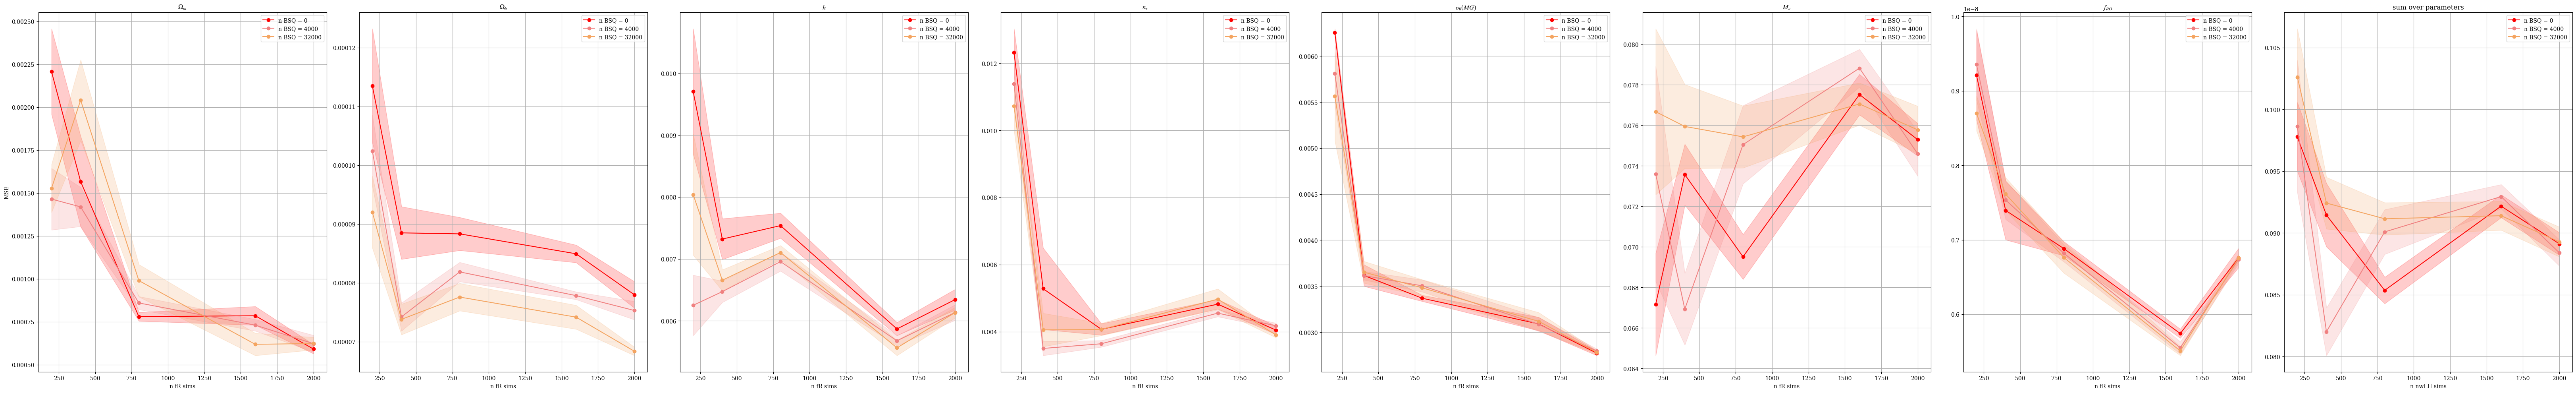

In [8]:
Pk_type = 'Pk'
cosm_type = 'fR'
n_sims_nwLH = [200 , 400, 800, 1600, 2000]
n_sims_BSQ = [0, 4000, 32000]

minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01, -3*10**(-4)])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0, 0])
colors = ['red', 'lightcoral', 'sandybrown', 'yellowgreen', 'mediumturquoise','mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8(MG)$', r'$M_{\nu}$', r'$f_{RO}$']
num_params = 7

fig, axes = plt.subplots(1, 8, figsize=(65, 10), sharey=False)

for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_avg_param_sum = []
    all_mse_std = []  # shape will be (len(n_sims_nwLH), num_params)
    all_mse_std_param_sum = []


    for n_nwLH in n_sims_nwLH:
        mse_all_models = []

        for n_model in range(10):
            additional_extension = '_MG'
            name = 'transfer10_network2_'+str(n_nwLH)+'_'+cosm_type+'_'+str(n_BSQ)+'_BSQ_MG'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6
            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)
        mse_param_sum = np.sum(mse_all_models, axis=1)  # shape: (10,)
        
        all_mse_avg.append(np.mean(mse_all_models, axis=0))  # (6,)
        all_mse_std.append(np.std(mse_all_models, axis=0))  # (6,)
        
        all_mse_avg_param_sum.append(np.mean(mse_param_sum))
        all_mse_std_param_sum.append(np.std(mse_param_sum))

        # for param_idx in range(num_params):
        #     ax = axes[param_idx]
        #     ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
        #     # ax.set_xscale('log')
        # axes[6].scatter([n_nwLH]*10, mse_param_sum, color=colors[color_idx], s=5)

    
    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params
    all_mse_avg_param_sum = np.array(all_mse_avg_param_sum)
    all_mse_std = np.array(all_mse_std)  # 5 n_sims_nwLH x 6 num_params
    all_mse_std_param_sum = np.array(all_mse_std_param_sum)

    for param_idx in range(num_params):
        ax = axes[param_idx]
        ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color=colors[color_idx], marker='o', label='n BSQ = '+str(n_BSQ))
        ax.fill_between(n_sims_nwLH,
                all_mse_avg[:, param_idx] - all_mse_std[:, param_idx],
                all_mse_avg[:, param_idx] + all_mse_std[:, param_idx],
                color=colors[color_idx],
                alpha=0.2)
        ax.set_title(param_labels[param_idx])
        ax.set_xlabel('n fR sims')
        if param_idx == 0:
            ax.set_ylabel('MSE')
        ax.grid(True)
        # ax.set_xscale('log')
    axes[num_params].plot(n_sims_nwLH, all_mse_avg_param_sum, color = colors[color_idx],  marker='o', label='n BSQ = '+str(n_BSQ))
    axes[num_params].fill_between(n_sims_nwLH,
                all_mse_avg_param_sum - all_mse_std_param_sum,
                all_mse_avg_param_sum + all_mse_std_param_sum,
                color=colors[color_idx],
                alpha=0.2)
    axes[num_params].grid(True)
    axes[num_params].set_title('sum over parameters')
    axes[num_params].set_xlabel('n nwLH sims')



# ## First network
# all_mse = []
# for n_BSQ in [2000, 4000, 8000, 16000, 32000]: 
#     name = 'transfer10_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
#     num_params = 5
#     additional_extension = ''
#     test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+str(additional_extension)+'.txt')
#     test_true = test[:, :num_params]
#     test_pred = test[:, num_params:]
#     minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
#     maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
#     test_true = test_true * (maximum - minimum) + minimum
#     test_pred = test_pred * (maximum - minimum) + minimum
#     mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
#     all_mse.append(mse)  # 5 n sims x 5 cosmo params

# all_mse = np.array(all_mse)
# for param_indx in range (5):
#     ax = axes[param_indx]
#     for BSQ_indx in range (5):
#         ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=2000, linestyle = '--', color = colors[BSQ_indx+1])




# axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
for ax in axes:
    # ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()




## Test BSQ on BSQ

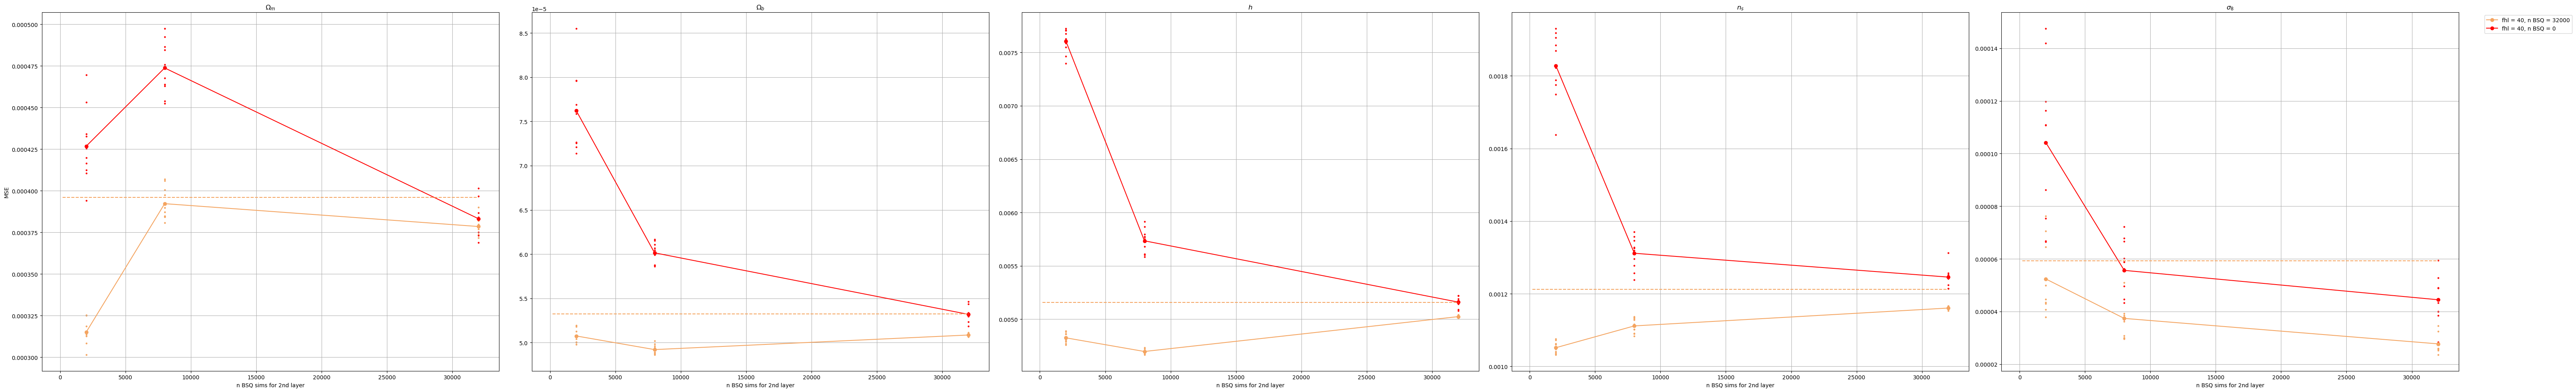

In [40]:
# first network fhl40
fig, axes = plt.subplots(1, 5, figsize=(65, 10), sharey=False)
colors = ['C0', 'C1', 'C2']

Pk_type = 'MPk'
cosm_type = 'BSQ'
n_sims_nwLH = [2000 , 8000, 32000]
n_sims_BSQ = [32000, 0]
n_models = 10
minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
colors = ['sandybrown', 'red', 'yellowgreen', 'lightcoral', 'thistle', 'mediumblue']
param_labels = [r'$\Omega_m$', r'$\Omega_b$', r'$h$', r'$n_s$', r'$\sigma_8$', r'$M_{\nu}$']
num_params = 5


# plot line for trined once on BSQ, trained w first network 32000 BSQ

for color_idx, n_BSQ in enumerate(n_sims_BSQ):
    all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)

    for n_nwLH in n_sims_nwLH:
        mse_all_models = []

        for n_model in range(n_models):
            # if n_BSQ == 0:
            #     additional_extension = 'v2'
            # else:
            additional_extension = ''
            
            name = 'transfer40_network2_'+str(n_nwLH)+'_BSQ_'+str(n_BSQ)+'_BSQ'
            test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

            test_true = test[:, :num_params]
            test_pred = test[:, num_params:]
            
            test_true = test_true * (maximum - minimum) + minimum
            test_pred = test_pred * (maximum - minimum) + minimum

            mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6

            mse_all_models.append(mse)  #size 10 x 6

        mse_all_models = np.array(mse_all_models)  # shape: (10, 6)

        avg_mse_per_param = np.mean(mse_all_models, axis=0)  # (6,)
        all_mse_avg.append(avg_mse_per_param)

        for param_idx in range(num_params):
            ax = axes[param_idx]
            ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color=colors[color_idx], s=5)
            # ax.set_xscale('log')

    all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params

    for param_idx in range(num_params):
        ax = axes[param_idx]
        ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color=colors[color_idx], marker='o', label='fhl = 40, n BSQ = '+str(n_BSQ))
        ax.set_title(param_labels[param_idx])
        ax.set_xlabel('n BSQ sims for 2nd layer')
        if param_idx == 0:
            ax.set_ylabel('MSE')
        ax.grid(True)
        # ax.set_xscale('log')


# plot horizontal line for first networks ie BSQ 32000, 
all_mse = []
n_sims_BSQ = [32000]
for n_BSQ in n_sims_BSQ: 
    name = 'transfer40_network1_'+str(n_BSQ)
    additional_extension = ''
    name = 'transfer40_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
    test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+additional_extension+'.txt')
    test_true = test[:, :num_params]
    test_pred = test[:, num_params:]
    test_true = test_true * (maximum - minimum) + minimum
    test_pred = test_pred * (maximum - minimum) + minimum
   
    mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
    all_mse.append(mse)  # 5 n sims x 5 cosmo params

all_mse = np.array(all_mse)
for param_indx in range (num_params):
    ax = axes[param_indx]
    for BSQ_indx in range(len(n_sims_BSQ)):
        ax.hlines(all_mse[BSQ_indx, param_indx], xmin=200, xmax=32000, linestyle = '--', color = colors[BSQ_indx])


axes[-1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [70]:
# ################################### INPUT ############################################
# # data parameters
# f_Pk_norm = None #file with Pk to normalize Pk
# seed      = 1         #seed to split data in train/valid/test
# mode      = 'test'   #'train','valid','test' or 'all'

# cosm_type = 'BSQ'
# Pk_type = 'Pk'
# log = True
# model_type = 'dynamic_fixed_final' #or 'dynamic' 'dynamic_fixed_final'
# output_size = 10
# input_size  = 79  #dimensions of input data
# final_hidden_layer_size = 10
# n_sims_BSQ = [2000, 4000, 8000, 16000, 32000]

# for n_BSQ in n_sims_BSQ: 

#     n = []
#     mse = []

#     name = 'transfer10_network1_'+str(n_BSQ)
#     f_params  = '../real_params/'+str(n_BSQ)+'_'+str(cosm_type)+'_params.txt'  
#     f_Pk      = 'Pk_files/'+str(n_BSQ)+'_'+str(Pk_type)+'_'+str(cosm_type)+'.npy'

#     study_name = str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)
#     mother = '/scratch/network/vk9342/USRP2024_scratch/pytorch/'+str(Pk_type)+'_'+str(cosm_type)+'/'+str(name)+'/models/'

#     # architecture parameters
#     # training parameters
#     batch_size = 32
#     # optuna parameters
#     storage    = 'sqlite:///nwLH.db'
    
    
    
#     ######################################################################################
#     ######################################################################################
#     # use GPUs if available
#     if torch.cuda.is_available():
#         print("CUDA Available")
#         device = torch.device('cuda')
#     else:
#         print('CUDA Not Available')
#         device = torch.device('cpu')
    
#     # load the optuna study
#     study = optuna.load_study(study_name=study_name, storage=storage)
    
#     # get the scores of the study trials
#     values = np.zeros(len(study.trials))
#     completed = 0
    
#     for i,t in enumerate(study.trials):
#         values[i] = t.value
#         if t.value is not None:  completed += 1
    
#     # get the info of the best trial
#     indexes = np.argsort(values)
#     for indx in [0]:
#         trial = study.trials[indexes[indx]]
#         fout = 'results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(indx)+'.txt'
#         # fout = 'results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+'transfer10_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ'+'model'+str(indx)+'.txt'
        
#         # print("\nTrial number {}".format(trial.number))
#         # print("Value: %.5e"%trial.value)
#         for key, value in trial.params.items():
#             lr       = trial.params['lr']
#             wd       = trial.params['wd']
#             n_layers       = trial.params['n_layers']
#             p       = trial.params['dropout_l']
            
#         fmodel = mother +'model_%d.pt'%trial.number
    
#         # # generate the architecture
#         if model_type == 'dynamic_fixed_final':
#             out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers-1)]
#             model = architecture.dynamic_model_fixed_final(trial, input_size, output_size, 
#                                                            final_hidden_layer_size, 
#                                                            n_layers, p, out_fs,
#                                                            max_neurons_layers=500)
            
#         elif model_type == 'dynamic':
#             out_fs = [trial.params[f'n_units_l{i}'] for i in range(n_layers)]
#             model = architecture.dynamic_model(trial, input_size, output_size,
#                                                n_layers, p, out_fs,
#                                                max_neurons_layers=500)   

#         else:
#             print('not a valid model')

#         # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'layer sizes: ', out_fs)
#         # print('N BSQ: ', str(n_BSQ), 'N nwLH: ', str(n_nwLH), 'n layers: ', n_layers)

        
#         model.to(device)  
        
#         # load best-model, if it exists
#         if os.path.exists(fmodel):  
#             print('Loading model...')
#             model.load_state_dict(torch.load(fmodel, map_location=torch.device(device)))
#         else:
#             raise Exception('model doesnt exists!!!')
        
        
#         # define loss function
#         criterion = nn.MSELoss() 
        
#         # get the data
#         test_loader = data.create_dataset(mode, seed, f_Pk, f_Pk_norm, f_params, 
#                                           batch_size, shuffle=False, workers=1, 
#                                           cosm_type =cosm_type, log=log, 
#                                           shuffle_all = True)
#         test_points = 0
#         for x,y in test_loader:  test_points += x.shape[0]
        
#         # define the arrays containing the true and predicted value of the parameters
#         params  = output_size
#         results = np.zeros((test_points, 2*params), dtype=np.float32)
        
#         # test the model
#         test_loss, points = 0.0, 0
#         model.eval()
#         with torch.no_grad():
#             for x, y in test_loader:
#                 bs   = x.shape[0]  #batch size
#                 x, y = x.to(device), y.to(device)
#                 y_NN = model(x)
#                 test_loss += (criterion(y_NN, y).item())*bs
#                 results[points:points+bs,0*params:1*params] = y.cpu().numpy()
#                 results[points:points+bs,1*params:2*params] = y_NN.cpu().numpy()
#                 points    += bs
#         test_loss /= points
#         print('Test loss:', test_loss)

#         np.savetxt(fout, results)


## Add BSQ40 test t first plot

In [ ]:
# #### fhl 40 plot
# num_params = 6
# for color_idx, n_BSQ in enumerate([32000]):
#     all_mse_avg = []  # shape will be (len(n_sims_nwLH), num_params)

#     for n_nwLH in n_sims_nwLH:
#         mse_all_models = []

#         for n_model in range(10):
#             if n_BSQ == 0:
#                 additional_extension = 'v2'
#             else:
#                 additional_extension = ''
#             name = 'transfer40_network2_'+str(n_nwLH)+'_nwLH_'+str(n_BSQ)+'_BSQ'
#             test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_'+str(cosm_type)+'_params_'+str(name)+'model'+str(n_model)+additional_extension+'.txt')

#             test_true = test[:, :num_params]
#             test_pred = test[:, num_params:]
            
#             minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60, 0.01])
#             maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00, 1.0])
#             test_true = test_true * (maximum - minimum) + minimum
#             test_pred = test_pred * (maximum - minimum) + minimum

#             mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 6

#             mse_all_models.append(mse)  #size 10 x 6

#         mse_all_models = np.array(mse_all_models)  # shape: (10, 6)

#         avg_mse_per_param = np.mean(mse_all_models, axis=0)  # (6,)
#         all_mse_avg.append(avg_mse_per_param)

#         for param_idx in range(num_params):
#             ax = axes[param_idx]
#             ax.scatter([n_nwLH]*10, mse_all_models[:, param_idx], color='black', s=5)
#             # ax.set_xscale('log')

#     all_mse_avg = np.array(all_mse_avg)  # 5 n_sims_nwLH x 6 num_params

#     for param_idx in range(num_params):
#         ax = axes[param_idx]
#         ax.plot(n_sims_nwLH, all_mse_avg[:, param_idx], color='black', marker='o', label='fhl = 40, n BSQ = '+str(n_BSQ))
#         ax.set_title(param_labels[param_idx])
#         ax.set_xlabel('n nwLH sims')
#         if param_idx == 0:
#             ax.set_ylabel('MSE')
#         ax.grid(True)
#         # ax.set_xscale('log')


# # # first network fhl40
# all_mse = []
# for n_BSQ in [32000]: 
#     name = 'transfer40_network1_'+str(n_BSQ)
#     num_params = 5
#     additional_extension = ''
#     name = 'transfer40_network1_0_nwLH_'+str(n_BSQ)+'_BSQ'
#     test = np.loadtxt('results/Results_test_'+str(Pk_type)+'_BSQ_params_'+str(name)+'model0'+additional_extension+'.txt')
#     test_true = test[:, :num_params]
#     test_pred = test[:, num_params:]
#     minimum = np.array([0.1, 0.02, 0.50, 0.80, 0.60])
#     maximum = np.array([0.5, 0.08, 0.90, 1.20, 1.00])
#     test_true = test_true * (maximum - minimum) + minimum
#     test_pred = test_pred * (maximum - minimum) + minimum
#     mse = [mean_squared_error(test_true[:, i], test_pred[:, i]) for i in range(num_params)]  #size 5, one for each param
#     all_mse.append(mse)  # 5 n sims x 5 cosmo params

# all_mse = np.array(all_mse)
# for param_indx in range (5):
#     ax = axes[param_indx]
#     ax.hlines(all_mse[:, param_indx], xmin=200, xmax=2000, linestyle = '--', color = 'black')



